# Análise Exploratória dos Dados de Segurança do ISP

## Configurações iniciais do projeto

Importando as bibliotecas e dados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../datasets/BaseDPEvolucaoMensalCisp.csv", sep=";", decimal=",", encoding="latin1")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37588 entries, 0 to 37587
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        37588 non-null  int64  
 1   mes                         37588 non-null  int64  
 2   ano                         37588 non-null  int64  
 3   mes_ano                     37588 non-null  str    
 4   aisp                        37588 non-null  int64  
 5   risp                        37588 non-null  int64  
 6   munic                       37588 non-null  str    
 7   mcirc                       37588 non-null  int64  
 8   regiao                      37588 non-null  str    
 9   hom_doloso                  37588 non-null  int64  
 10  lesao_corp_morte            37588 non-null  int64  
 11  latrocinio                  37588 non-null  int64  
 12  cvli                        37588 non-null  int64  
 13  hom_por_interv_policial     37588 non-null

Determinando paleta de cores dos gráficos

In [ ]:
sns.set_palette(palette='PiYG')

[(0.8129181084198386, 0.2544405997693195, 0.5693194925028835),
 (0.9348712033833141, 0.6798154555940021, 0.8312187620146096),
 (0.9856978085351787, 0.9031910803537101, 0.9458669742406767),
 (0.9202614379084968, 0.9629373317954633, 0.8576701268742792),
 (0.6908881199538641, 0.8624375240292197, 0.4883506343713959),
 (0.38269896193771624, 0.6403690888119954, 0.18108419838523643)]

In [5]:
# pegar apenas os dados da Capital e da Baixada
df = df[df["regiao"].isin(["Capital", "Baixada Fluminense"])]
df.info()

<class 'pandas.DataFrame'>
Index: 16472 entries, 0 to 37510
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        16472 non-null  int64  
 1   mes                         16472 non-null  int64  
 2   ano                         16472 non-null  int64  
 3   mes_ano                     16472 non-null  str    
 4   aisp                        16472 non-null  int64  
 5   risp                        16472 non-null  int64  
 6   munic                       16472 non-null  str    
 7   mcirc                       16472 non-null  int64  
 8   regiao                      16472 non-null  str    
 9   hom_doloso                  16472 non-null  int64  
 10  lesao_corp_morte            16472 non-null  int64  
 11  latrocinio                  16472 non-null  int64  
 12  cvli                        16472 non-null  int64  
 13  hom_por_interv_policial     16472 non-null  int

Percebemos que as regiões com mais incidência são bairros nobres, como Barra da Tijuca e Botafogo. Pensamos em duas interpretações disso:
1. Existe um viés no dado, pois esses contam apenas os furtos reportados e registrados.
2. Os dados ainda não estão normalizados pela quantidade de pessoas.
Podemos evitar o 2 ao relacionar com a população de cada bairro, porém precisamos de dados os quais ainda não temos para isso.

Verificamos que não temos nulos.

In [6]:
df.isna().sum()

cisp                         0
mes                          0
ano                          0
mes_ano                      0
aisp                         0
                            ..
encontro_ossada              0
pol_militares_mortos_serv    0
pol_civis_mortos_serv        0
registro_ocorrencias         0
fase                         0
Length: 65, dtype: int64

Verificando que os dados pegam o histórico de 2003 até 2026.

In [7]:
print(f"Min: {df["ano"].min()}, Max: {df["ano"].max()}")

Min: 2003, Max: 2026


## Exploração de furtos e roubos em coletivos

In [8]:
df_coletivo = df[["roubo_em_coletivo", "furto_coletivo", "cisp"]]
df_coletivo.groupby("cisp").sum().sort_values("furto_coletivo")

,roubo_em_coletivo,furto_coletivo
cisp,,
45,18,20
67,66,50
51,53,60
61,276,148
63,317,207
...,...,...
35,4602,5857
4,4175,6744
32,4992,6832


In [9]:
# sns.heatmap(df[["furto_coletivo", "cisp"]].corr())

df[["furto_coletivo", "roubo_em_coletivo", "hom_culposo", "hom_doloso"]].corr()

,furto_coletivo,roubo_em_coletivo,hom_culposo,hom_doloso
furto_coletivo,1.000000,0.224722,0.061425,-0.099689
roubo_em_coletivo,0.224722,1.000000,0.227111,0.281328
hom_culposo,0.061425,0.227111,1.000000,0.368561
hom_doloso,-0.099689,0.281328,0.368561,1.000000


<Axes: xlabel='ano', ylabel='total_roubos'>

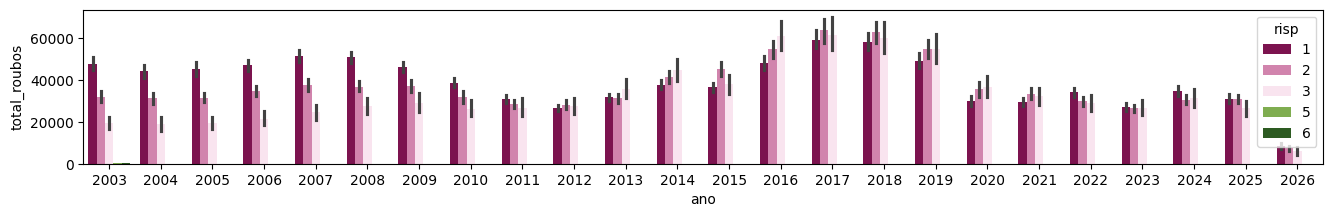

In [10]:
# df[["furto_coletivo", "ano"]].plot(x="ano")
plt.figure(figsize=(16,2))
sns.barplot(data=df, x="ano", y="total_roubos", hue="risp", estimator="sum", palette='PiYG')
# df.plot.line(x="ano", y="furto_coletivo", hue="cisp")